In [106]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score, precision_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [107]:
df = pd.read_csv('dataset.csv')
df.columns = [i for i in range(df.shape[1])]
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.643946,0.709632,-5.444120e-07,0.579762,0.667507,-0.002146,0.547147,0.610325,-0.002921,0.541985,...,0.662553,0.513652,-0.017327,0.653451,0.550719,-0.006435,0.654402,0.577736,0.005366,a
1,0.641340,0.702666,-6.188903e-07,0.571356,0.661613,-0.003557,0.535324,0.599465,-0.004988,0.528244,...,0.657429,0.491781,-0.021528,0.650007,0.532530,-0.008465,0.652505,0.560191,0.004924,a
2,0.620618,0.698781,-6.253034e-07,0.547723,0.653062,-0.001439,0.511769,0.585549,-0.001712,0.505976,...,0.639563,0.472737,-0.021090,0.628351,0.514149,-0.008011,0.629103,0.544881,0.005451,a
3,0.572995,0.701376,-6.388161e-07,0.497214,0.655691,-0.002461,0.459139,0.585994,-0.003752,0.453124,...,0.589433,0.463170,-0.024838,0.580155,0.506553,-0.011476,0.583571,0.539416,0.002034,a
4,0.515520,0.716109,-6.691291e-07,0.441058,0.672066,-0.000944,0.402906,0.599529,-0.001493,0.395844,...,0.529307,0.467894,-0.026447,0.515936,0.514172,-0.012920,0.520426,0.548778,0.000881,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d
695,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d
696,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d
697,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d


In [108]:
df = df.rename(columns={63: 'Output'})
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,Output
0,0.643946,0.709632,-5.444120e-07,0.579762,0.667507,-0.002146,0.547147,0.610325,-0.002921,0.541985,...,0.662553,0.513652,-0.017327,0.653451,0.550719,-0.006435,0.654402,0.577736,0.005366,a
1,0.641340,0.702666,-6.188903e-07,0.571356,0.661613,-0.003557,0.535324,0.599465,-0.004988,0.528244,...,0.657429,0.491781,-0.021528,0.650007,0.532530,-0.008465,0.652505,0.560191,0.004924,a
2,0.620618,0.698781,-6.253034e-07,0.547723,0.653062,-0.001439,0.511769,0.585549,-0.001712,0.505976,...,0.639563,0.472737,-0.021090,0.628351,0.514149,-0.008011,0.629103,0.544881,0.005451,a
3,0.572995,0.701376,-6.388161e-07,0.497214,0.655691,-0.002461,0.459139,0.585994,-0.003752,0.453124,...,0.589433,0.463170,-0.024838,0.580155,0.506553,-0.011476,0.583571,0.539416,0.002034,a
4,0.515520,0.716109,-6.691291e-07,0.441058,0.672066,-0.000944,0.402906,0.599529,-0.001493,0.395844,...,0.529307,0.467894,-0.026447,0.515936,0.514172,-0.012920,0.520426,0.548778,0.000881,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d
695,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d
696,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d
697,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,d


In [109]:
X = df.iloc[:, :-1]
print("Features shape =", X.shape)

Y = df.iloc[:, -1]
print("Labels shape =", Y.shape)

Features shape = (699, 63)
Labels shape = (699,)


In [110]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
svm = SVC(C=10, gamma=0.1, kernel='rbf')
svm.fit(x_train, y_train)

SVC(C=10, gamma=0.1)

In [111]:
y_pred = svm.predict(x_test)
y_pred

array(['b', 'c', 'a', 'b', 'a', 'b', 'c', 'a', 'c', 'b', 'd', 'd', 'c',
       'a', 'a', 'a', 'd', 'b', 'd', 'c', 'b', 'd', 'a', 'd', 'c', 'a',
       'a', 'c', 'd', 'a', 'a', 'c', 'b', 'a', 'b', 'd', 'b', 'c', 'a',
       'a', 'a', 'a', 'b', 'b', 'c', 'c', 'd', 'c', 'b', 'c', 'a', 'b',
       'd', 'c', 'c', 'b', 'b', 'c', 'a', 'a', 'a', 'c', 'a', 'b', 'a',
       'c', 'c', 'b', 'b', 'd', 'd', 'd', 'a', 'b', 'd', 'c', 'b', 'c',
       'c', 'c', 'd', 'c', 'a', 'b', 'd', 'd', 'b', 'd', 'b', 'c', 'b',
       'c', 'b', 'c', 'a', 'c', 'a', 'b', 'b', 'c', 'b', 'd', 'd', 'a',
       'a', 'c', 'd', 'c', 'b', 'd', 'b', 'd', 'a', 'c', 'a', 'b', 'b',
       'c', 'a', 'c', 'b', 'b', 'a', 'a', 'c', 'd', 'a', 'a', 'a', 'b',
       'c', 'a', 'b', 'c', 'a', 'd', 'd', 'c', 'b', 'a'], dtype=object)

In [112]:
cf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
precision = precision_score(y_test, y_pred, average='micro')
f1, recall, precision

(0.9642857142857143, 0.9642857142857143, 0.9642857142857143)

<Axes: title={'center': 'Confusion Matrix - American Sign Language'}>

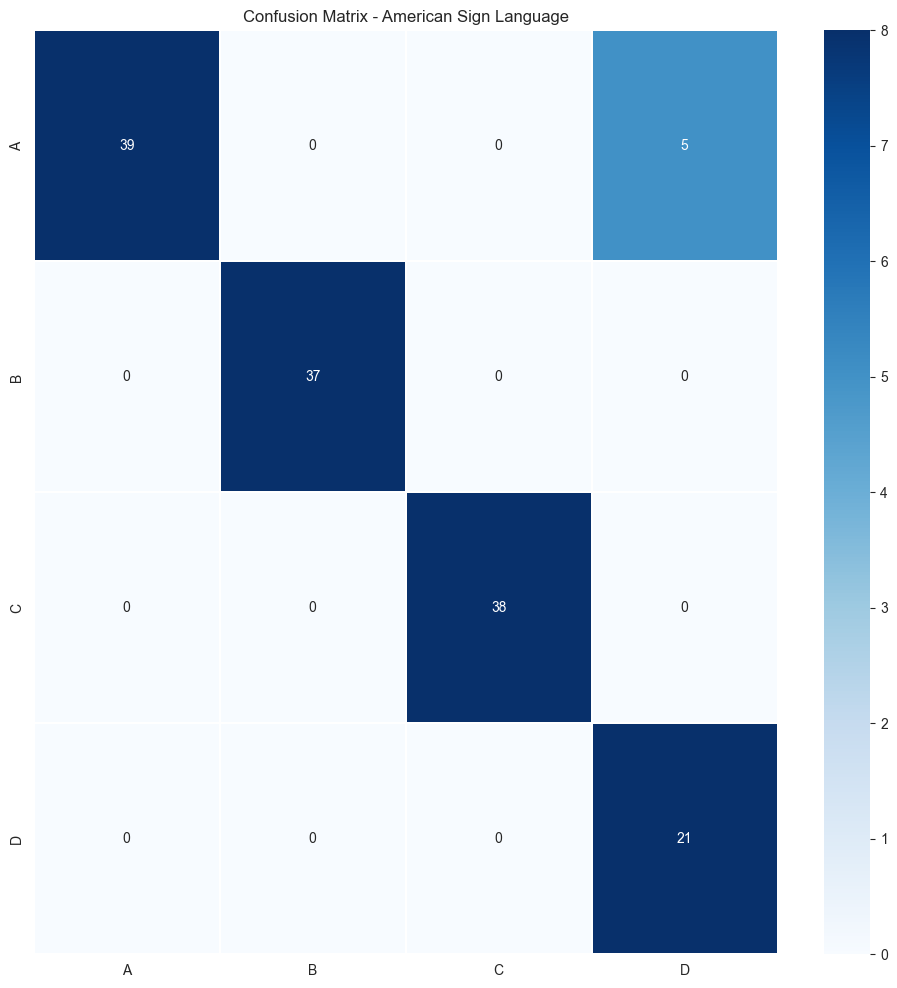

In [113]:
labels = sorted(list(set(df['Output'])))
labels = [x.upper() for x in labels]

fig, ax = plt.subplots(figsize=(12, 12))

ax.set_title("Confusion Matrix - American Sign Language")

maping = sns.heatmap(cf_matrix, 
                     annot=True,
                     cmap = plt.cm.Blues, 
                     linewidths=.2,
                     xticklabels=labels,
                     yticklabels=labels, vmax=8,
                     fmt='g',
                     ax=ax
                    )
maping

In [114]:
import pickle

# save model
with open('model.pkl','wb') as f:
    pickle.dump(svm,f)